# Ground Truth Perception to Comfort Model

This notebook tests the "theoretical maximum" performance of our Phase 2 model. 
If we feed the model the **actual ground-truth perception labels** that the users reported (e.g. they explicitly told us the room is "Warm" or "Noisy"), can we accurately predict their final 1-5 Comfort score?

If this model has high accuracy and a strong diagonal confusion matrix, it means human comfort *can* be predicted from perceptions. If this model *fails*, it means that even if a user tells us a room is "Warm", their resulting Comfort score is still completely random due to personal preference!


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
# 1. Load Data
data_path = '../../data/raw/DATA_8/smart-campus-comfort-data/4_comfort_perception.csv'
df = pd.read_csv(data_path)

# Map target and features
perception_cols = ['temperatureValue', 'humidityValue', 'noiseValue', 'airQualityValue']
target_col = 'comfortValue'

# Clean data
df = df[perception_cols + [target_col]].copy()
df = df.dropna()

for col in perception_cols + [target_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

print(f"Total rows for Ground-Truth Perception Model: {len(df):,}")


Total rows for Ground-Truth Perception Model: 1,830


In [3]:
# 2. Train/Test Split
X = df[perception_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")


Train size: 1464
Test size: 366


In [4]:
# 3. One-Hot Encoding the Perceptions
# Because "temperatureValue" is nominal (e.g. -1: Cool, 0: Optimal, 1: Warm), we must One-Hot Encode them
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

encoded_cols = encoder.get_feature_names_out(X_train.columns)
X_train_final = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
X_test_final = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)

print("\nFeature Set (Ground-Truth Perceptions):")
display(X_train_final.head())



Feature Set (Ground-Truth Perceptions):


,temperatureValue_-2,temperatureValue_-1,temperatureValue_0,temperatureValue_1,temperatureValue_2,humidityValue_-2,humidityValue_-1,humidityValue_0,humidityValue_1,humidityValue_2,noiseValue_0,noiseValue_1,noiseValue_2,airQualityValue_0,airQualityValue_1,airQualityValue_2
529,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1676,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1730,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
988,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
182,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [5]:
# 4. Train Models

# ---- REGRESSOR ----
regressor = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
regressor.fit(X_train_final, y_train)

test_preds_reg = regressor.predict(X_test_final)
train_preds_reg = regressor.predict(X_train_final)

test_preds_reg_rounded = np.clip(np.round(test_preds_reg), y_train.min(), y_train.max())
train_preds_reg_rounded = np.clip(np.round(train_preds_reg), y_train.min(), y_train.max())

mae_reg_test = mean_absolute_error(y_test, test_preds_reg)
mae_reg_train = mean_absolute_error(y_train, train_preds_reg)

print("--- Regressor Results ---")
print(f"TRAIN MAE: {mae_reg_train:.3f}")
print(f"TEST MAE: {mae_reg_test:.3f}")

# ---- CLASSIFIER ----
# We use standard classification with balanced class weights to give rare extremes a fair chance
classifier = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
classifier.fit(X_train_final, y_train)

test_preds_clf = classifier.predict(X_test_final)
train_preds_clf = classifier.predict(X_train_final)

acc_clf_test = accuracy_score(y_test, test_preds_clf)
acc_clf_train = accuracy_score(y_train, train_preds_clf)
mae_clf_test = mean_absolute_error(y_test, test_preds_clf)
mae_clf_train = mean_absolute_error(y_train, train_preds_clf)

print("\n--- Classifier Results ---")
print(f"TRAIN Accuracy: {acc_clf_train:.3f}  |  TRAIN MAE: {mae_clf_train:.3f}")
print(f"TEST Accuracy: {acc_clf_test:.3f}   |  TEST MAE: {mae_clf_test:.3f}")


--- Regressor Results ---
TRAIN MAE: 0.581
TEST MAE: 0.629

--- Classifier Results ---
TRAIN Accuracy: 0.408  |  TRAIN MAE: 0.844
TEST Accuracy: 0.331   |  TEST MAE: 0.934


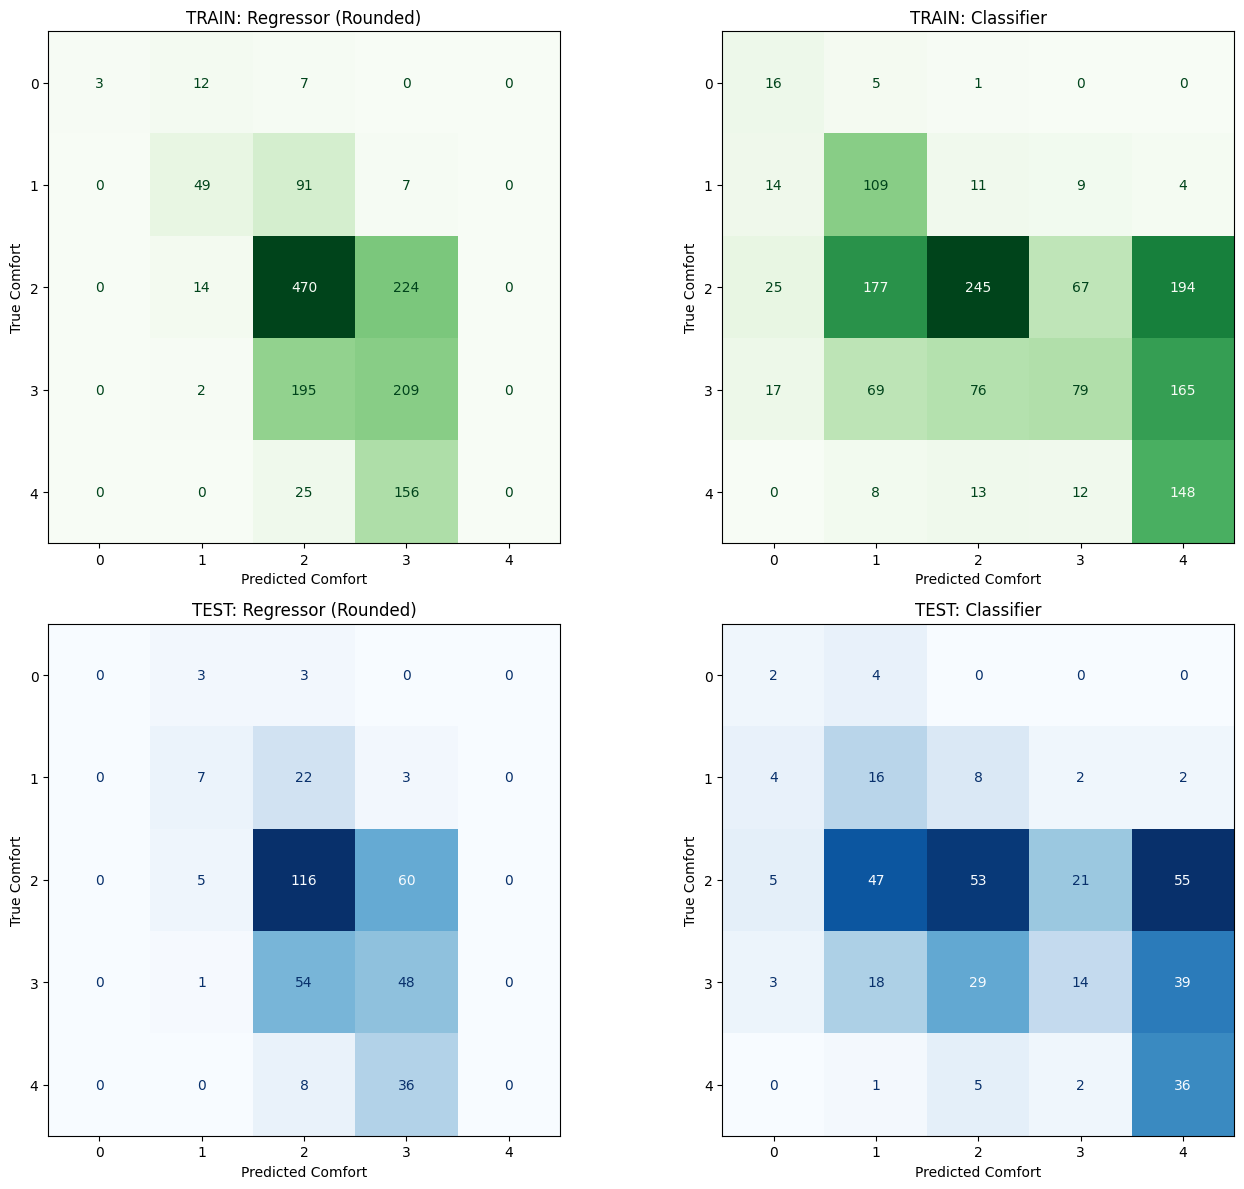

In [6]:
# 5. Confusion Matrices (Train vs Test)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- TRAINING DATA (Top Row) ---
# Train: Regressor
cm_reg_train = confusion_matrix(y_train, train_preds_reg_rounded)
disp_reg_train = ConfusionMatrixDisplay(confusion_matrix=cm_reg_train)
disp_reg_train.plot(ax=axes[0, 0], cmap='Greens', colorbar=False)
axes[0, 0].set_title('TRAIN: Regressor (Rounded)')
axes[0, 0].set_xlabel('Predicted Comfort')
axes[0, 0].set_ylabel('True Comfort')

# Train: Classifier
cm_clf_train = confusion_matrix(y_train, train_preds_clf)
disp_clf_train = ConfusionMatrixDisplay(confusion_matrix=cm_clf_train)
disp_clf_train.plot(ax=axes[0, 1], cmap='Greens', colorbar=False)
axes[0, 1].set_title('TRAIN: Classifier')
axes[0, 1].set_xlabel('Predicted Comfort')
axes[0, 1].set_ylabel('True Comfort')

# --- TESTING DATA (Bottom Row) ---
# Test: Regressor
cm_reg_test = confusion_matrix(y_test, test_preds_reg_rounded)
disp_reg_test = ConfusionMatrixDisplay(confusion_matrix=cm_reg_test)
disp_reg_test.plot(ax=axes[1, 0], cmap='Blues', colorbar=False)
axes[1, 0].set_title('TEST: Regressor (Rounded)')
axes[1, 0].set_xlabel('Predicted Comfort')
axes[1, 0].set_ylabel('True Comfort')

# Test: Classifier
cm_clf_test = confusion_matrix(y_test, test_preds_clf)
disp_clf_test = ConfusionMatrixDisplay(confusion_matrix=cm_clf_test)
disp_clf_test.plot(ax=axes[1, 1], cmap='Blues', colorbar=False)
axes[1, 1].set_title('TEST: Classifier')
axes[1, 1].set_xlabel('Predicted Comfort')
axes[1, 1].set_ylabel('True Comfort')

plt.tight_layout()
plt.show()
